In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
# --- HYPERPARAMS ---
input_size = 784 # 28x28
hidden_size = 500 
num_classes = 10
num_epochs = 2
batch_size = 64
learning_rate = 0.001

In [5]:
# --- DATA ---
train_dataset = torchvision.datasets.MNIST(root='./data', 
                                           train=True, 
                                           transform=transforms.ToTensor(),  
                                           download=True)
train_dataset

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:13<00:00, 727kB/s] 


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 141kB/s]


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:05<00:00, 310kB/s] 


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]

Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw



Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [7]:
test_dataset = torchvision.datasets.MNIST(root='./data', 
                                          train=False, 
                                          transform=transforms.ToTensor())
test_dataset

Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [9]:
# Data loader
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, 
                                           batch_size=batch_size, 
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset, 
                                          batch_size=batch_size, 
                                          shuffle=False)

examples = iter(test_loader)
example_data, example_targets = next(examples)

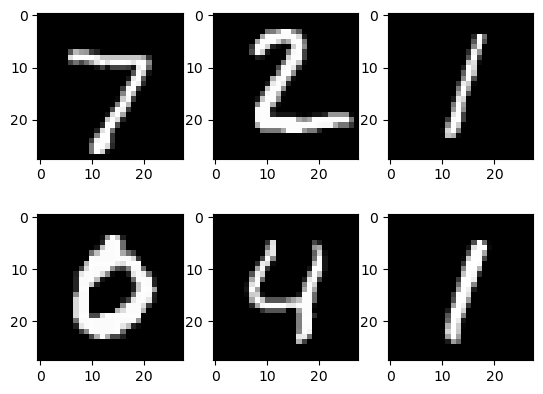

In [11]:
#data visualization
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(example_data[i][0], cmap='gray')
plt.show()

In [23]:
# --- MODEL ---
# Fully connected neural network with one hidden layer
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet, self).__init__()
        self.input_size = input_size
        self.l1 = nn.Linear(input_size, hidden_size) 
        self.relu = nn.ReLU()
        self.l2 = nn.Linear(hidden_size, num_classes)
        self.drop = nn.Dropout(0.5)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten
        out = self.l1(x)
        out = self.relu(out)
        out = self.drop(out)
        out = self.l2(out)
        # no activation and no softmax at the end
        return out

model = NeuralNet(input_size, hidden_size, num_classes)

In [25]:
# --- LOSS & OPTIMIZER ---
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) 

Epoch [1/2], Batch [100/938], Loss: 0.1376
Epoch [1/2], Batch [200/938], Loss: 0.0633
Epoch [1/2], Batch [300/938], Loss: 0.0697
Epoch [1/2], Batch [400/938], Loss: 0.0513
Epoch [1/2], Batch [500/938], Loss: 0.0163
Epoch [1/2], Batch [600/938], Loss: 0.0364
Epoch [1/2], Batch [700/938], Loss: 0.0384
Epoch [1/2], Batch [800/938], Loss: 0.0266
Epoch [1/2], Batch [900/938], Loss: 0.1287
Test Accuracy after Epoch 1: 98.07%

Epoch [2/2], Batch [100/938], Loss: 0.0149
Epoch [2/2], Batch [200/938], Loss: 0.0556
Epoch [2/2], Batch [300/938], Loss: 0.0258
Epoch [2/2], Batch [400/938], Loss: 0.0534
Epoch [2/2], Batch [500/938], Loss: 0.0575
Epoch [2/2], Batch [600/938], Loss: 0.0804
Epoch [2/2], Batch [700/938], Loss: 0.1908
Epoch [2/2], Batch [800/938], Loss: 0.0307
Epoch [2/2], Batch [900/938], Loss: 0.0611
Test Accuracy after Epoch 2: 98.03%



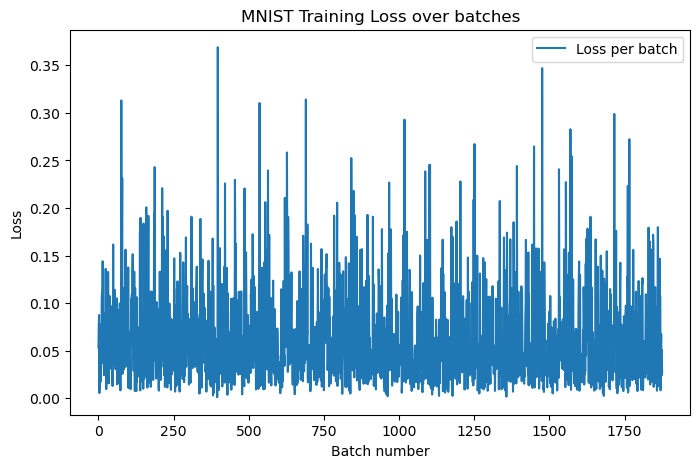

In [33]:
import matplotlib.pyplot as plt

# --- przygotowanie list do wykresu ---
all_losses = []

# --- TRAINING LOOP ---
for epoch in range(num_epochs):
    model.train()
    
    for batch_idx, (images, labels) in enumerate(train_loader):
        # forward
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # zapisujemy stratę do listy
        all_losses.append(loss.item())
        
        # druk co 100 batchy
        if (batch_idx + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}")
    
    # testowanie
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    print(f"Test Accuracy after Epoch {epoch+1}: {accuracy:.2f}%\n")

# --- WYKRES STRATY ---
plt.figure(figsize=(8,5))
plt.plot(all_losses, label="Loss per batch")
plt.xlabel("Batch number")
plt.ylabel("Loss")
plt.title("MNIST Training Loss over batches")
plt.legend()
plt.show()

In [ ]:
# --- OPCJONALNE TESTOWOWANIE NA WŁASNYCH OBRAZACH ---
from PIL import Image
import torchvision.transforms as transforms
import torch

# tryb ewaluacyjny
model.eval()

# transformacje MUSZĄ być takie same jak dla testu
transform = transforms.Compose([
    transforms.Grayscale(),        # upewnij się, że 1 kanał
    transforms.Resize((28, 28)),   # dopasowanie do MNIST
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# wczytaj obraz
image = Image.open("my_digit.png")

# zastosuj transformacje
image = transform(image)

# dodaj wymiar batcha: [1, 1, 28, 28]
image = image.unsqueeze(0)

# predykcja
with torch.no_grad():
    outputs = model(image)
    _, predicted = torch.max(outputs, 1)

print(f"Predicted digit: {predicted.item()}")